<center> <img src="https://miro.medium.com/v2/resize:fit:1250/format:webp/1*QgI1t-7yJApi4vQigFgsLQ.jpeg" width=25% > </center>

<br><br>

<center> 
    <font size="6">Final Lab (Part 1): Keypoint Detection, Bag of Visual Words and Image Classification</font>
</center>
<center> 
    <font size="4">Computer Vision 1 University of Amsterdam</font> 
</center>
<center> 
    <font size="4">Due 23:59PM, 24th October, 2025 (Amsterdam time)</font> 
</center>

<br><br>

***

<br><br>

<center>

Student1 ID:  \
Student1 Name: 

Student2 ID: \
Student2 Name: 

Student3 ID: \
Student3 Name: 

( Student4 ID: \
Student4 Name: )

</center>

### **General Guidelines**

Your code must be handed in this Jupyter notebook, renamed to **StudentID1_StudentID2_StudentID3.ipynb** before the deadline by submitting it to the Canvas Final Lab (Part 1) Assignment. Please also fill out your names and IDs above.

For full credit, make sure your notebook follows these guidelines:

- Please express your thoughts **concisely**. The number of words does not necessarily correlate with how well you understand the concepts.
- Understand the problem as much as you can. When answering a question, provide evidence (qualitative and/or quantitative results, references to papers, figures, etc.) to support your arguments. Not everything might be explicitly asked for, so think about what might strengthen your arguments to make the notebook self-contained and complete.
- Tables and figures must be accompanied by a **brief** description. Add a number, a title, and, if applicable, the name and unit of variables in a table, and name and unit of axes and legends in a figure.

**Late submissions are not allowed.** Assignments submitted after the strict deadline will not be graded. In case of submission conflicts, TAs’ system clock is taken as reference. We strongly recommend submitting well in advance to avoid last-minute system failure issues.

**Environment:** Since this is a project-based assignment, you are free to use any feature descriptor and machine learning tools (e.g., K-means, SVM). You should use Python for your implementation. You are free to use any Python library for this assignment, but make sure to provide a conda environment file!

**Plagiarism Note:** Keep in mind that plagiarism (submitted materials which are not your work) is a serious offense and any misconduct will be addressed according to university regulations. This includes using generative tools such as ChatGPT.

**Ensure that you save all results/answers to the questions (even if you reuse some code).**

### **Report Preparation**

Your tasks include the following:

1. **Report Preparation:** For both parts of the final project, students are expected to prepare a report. The report should include all details on implementation approaches, analysis of results for different settings, and visualizations illustrating experiments and performance of your implementation. Grading will be based on the report, so it should be as self-contained as possible. If the report contains faulty results or ambiguities, TAs can refer to your code for clarification. Only section 10 of this notebook should **not** be included in the report.

2. **Explanation of Results:** Do not just provide numbers without explanation. Discuss different settings to show your understanding of the material and processes involved.

3. **Quantitative Evaluation:** For quantitative evaluation, you are expected to provide the results based on the mAP (mean Average Precision) metric. You should report the mAP for each experimental setup. 

4. **Qualitative Evaluation:** For qualitative evaluation, you are expected to visualize the top-5 and bottom-5 ranked test images (based on classifier confidence for the target class) per setup. Provide a figure for each experimental setup Visual elements such as charts, graphs, and plots are always useful. Keep this in mind while writing your reports.

5. **Aim:** Understand the basic Image Classification pipeline using a traditional Bag of Visual Words method.

6. **Working on Assignments:** Students should work in assigned groups for **two** weeks. Any questions can be discussed on ED.

    - **Submission:** Submit your source code and report together in a zip file (`ID1_ID2_ID3_part1.zip`). The report should be a maximum of 10 pages (single-column, including tables and figures, excluding references and appendix). Express thoughts concisely. Tables and figures must be accompanied by a description. Number them and, if applicable, name variables in tables, and label axes in figures.

7. **Hyperparameter Search:** In your experiments, remember to perform a hyperparameter search to find the optimal settings for your classifier. Clearly document the search process, the parameters you explored, and how they influenced the performance of your model.

8. **Format and Testing:** The report should be in **PDF format**, and the code in **.ipynb format**. Test that all functionality works as expected in the notebook.

### **Overview**

- [Section 1: Data Preparation (0 points)](#section-1)
- [Section 2: Keypoint Detection and Feature Extraction (3 points)](#section-2)
- [Section 3: Building the Visual Vocabulary (3 points)](#section-3)
- [Section 4: Encoding Train Image Features (3 points)](#section-4)
- [Section 5: Visualizing the Bag of Visual Words for Each Class (3 points)](#section-5)
- [Section 6: Encoding Test Image Features (0 points)](#section-6)
- [Section 7: Training the Classifiers (5 points)](#section-7)
- [Section 8: Evaluating the Classifiers (12 points)](#section-8)
- [Section 9: Hyperparameter Search (16 points)](#section-9)
- [Section 10: Using CLIP for Image Classification (5 points)](#section-10)
- [Section X: Individual Contribution Report (Mandatory)](#section-x)

### **Section 1: Data Preparation (0 points)**

The goal of this lab is to implement an image classification system that can identify objects from a given set of classes. You will perform a 5-class image classification using a bag-of-words approach ([reference](http://www.robots.ox.ac.uk/~az/icvss08_az_bow.pdf)). The classes for this task are:

1. **Frog**
2. **Automobile**
3. **Bird**
4. **Cat**
5. **Deer**

The [CIFAR-10 dataset](https://www.cs.toronto.edu/~kriz/cifar.html) will be used for this task. This dataset contains 32x32 pixel RGB images, divided into sub-directories with 5000 training images and 1000 test images for each class.

The dataset will be automatically downloaded using the code provided in this notebook. You will need to perform training on the training set, which will later be divided into two subsets: one for building the visual vocabulary and another for training the classifier. Using more samples for training generally results in better performance. However, if computational resources are limited, you may use fewer training images to save time, as long as at least 500 images per class are included.

The system must be tested using the specified subset of test images. Use all 1000 test images (per class) to observe the full performance of the model. Ensure that test images are excluded from training to maintain a fair comparison.

In [119]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, Subset
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Define total train and test sizes
total_train_size = 5000  # Default value for total training images
total_test_size = 1000   # Default value for total test images

# Define batch sizes for DataLoader
train_batch_size = total_train_size
test_batch_size = total_test_size

# Define the number of Visual Words
num_of_visual_words = 1000  # Default value for number of visual words

# Number of classes
num_classes = 5

# Compute images per class for training and testing
images_per_class_train = total_train_size // num_classes  # e.g., 5000 // 5 = 1000 per class
images_per_class_test = total_test_size // num_classes    # e.g., 1000 // 5 = 200 per class

# Define the transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  
])

# Define the class indices for the 5 selected classes: frog, automobile, bird, cat, and deer
selected_classes = [6, 1, 2, 3, 4]  # 6: frog, 1: automobile, 2: bird, 3: cat, 4: deer
class_to_label = {orig_class: new_label for new_label, orig_class in enumerate(selected_classes)}

# Load the CIFAR-10 training set
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# Function to filter and remap dataset
def filter_dataset(dataset, images_per_class, selected_classes, class_to_label):
    selected_indices = []
    class_counts = {class_idx: 0 for class_idx in selected_classes}
    remapped_labels = []

    for idx, (image, label) in enumerate(dataset):
        if label in selected_classes and class_counts[label] < images_per_class:
            selected_indices.append(idx)
            remapped_labels.append(class_to_label[label])
            class_counts[label] += 1

            # Stop if we have enough samples for each class
            if all(count >= images_per_class for count in class_counts.values()):
                break

    filtered_dataset = Subset(dataset, selected_indices)
    return filtered_dataset, remapped_labels

# Filter and remap training set
filtered_train_set, train_mapped_labels = filter_dataset(train_set, images_per_class_train, selected_classes, class_to_label)

# Load the CIFAR-10 test set
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Filter and remap test set
filtered_test_set, test_mapped_labels = filter_dataset(test_set, images_per_class_test, selected_classes, class_to_label)

# Create data loaders for the filtered datasets
train_data_loader = DataLoader(filtered_train_set, batch_size=train_batch_size, shuffle=False)
test_data_loader = DataLoader(filtered_test_set, batch_size=test_batch_size, shuffle=False)

# Extract all training data and remapped labels
train_images, _ = next(iter(train_data_loader))
train_labels = torch.tensor(train_mapped_labels)

train_images = train_images.permute(0, 2, 3, 1)
print(f"Filtered train data: {train_images.shape}")
print(f"Filtered train labels: {train_labels.shape}")

# Extract all test data and remapped labels
test_images, _ = next(iter(test_data_loader))
test_labels = torch.tensor(test_mapped_labels)

test_images = test_images.permute(0, 2, 3, 1)
print(f"Filtered test data: {test_images.shape}")
print(f"Filtered test labels: {test_labels.shape}")

Files already downloaded and verified
Files already downloaded and verified
Filtered train data: torch.Size([5000, 32, 32, 3])
Filtered train labels: torch.Size([5000])
Filtered test data: torch.Size([1000, 32, 32, 3])
Filtered test labels: torch.Size([1000])


<a id="section-2"></a>
### **Section 2: Keypoint Detection and Feature Extraction (3 points)**

In this section, you will work on detecting keypoints and extracting features from the dataset. Your task is to use **two different feature extraction techniques** to identify keypoints in the images. Visualize two images from each of the five classes (Frog, Automobile, Bird, Cat, Deer) for both feature extraction techniques. For each image, draw circles around the detected keypoints that represent their size.

This step is essential to understand how different feature extractors behave across various classes, setting the foundation for further analysis and classification in later steps.

**Hint:** You can use the OpenCV library to detect keypoints and extract features. You can also upscale the images to improve the visualization of the keypoints.

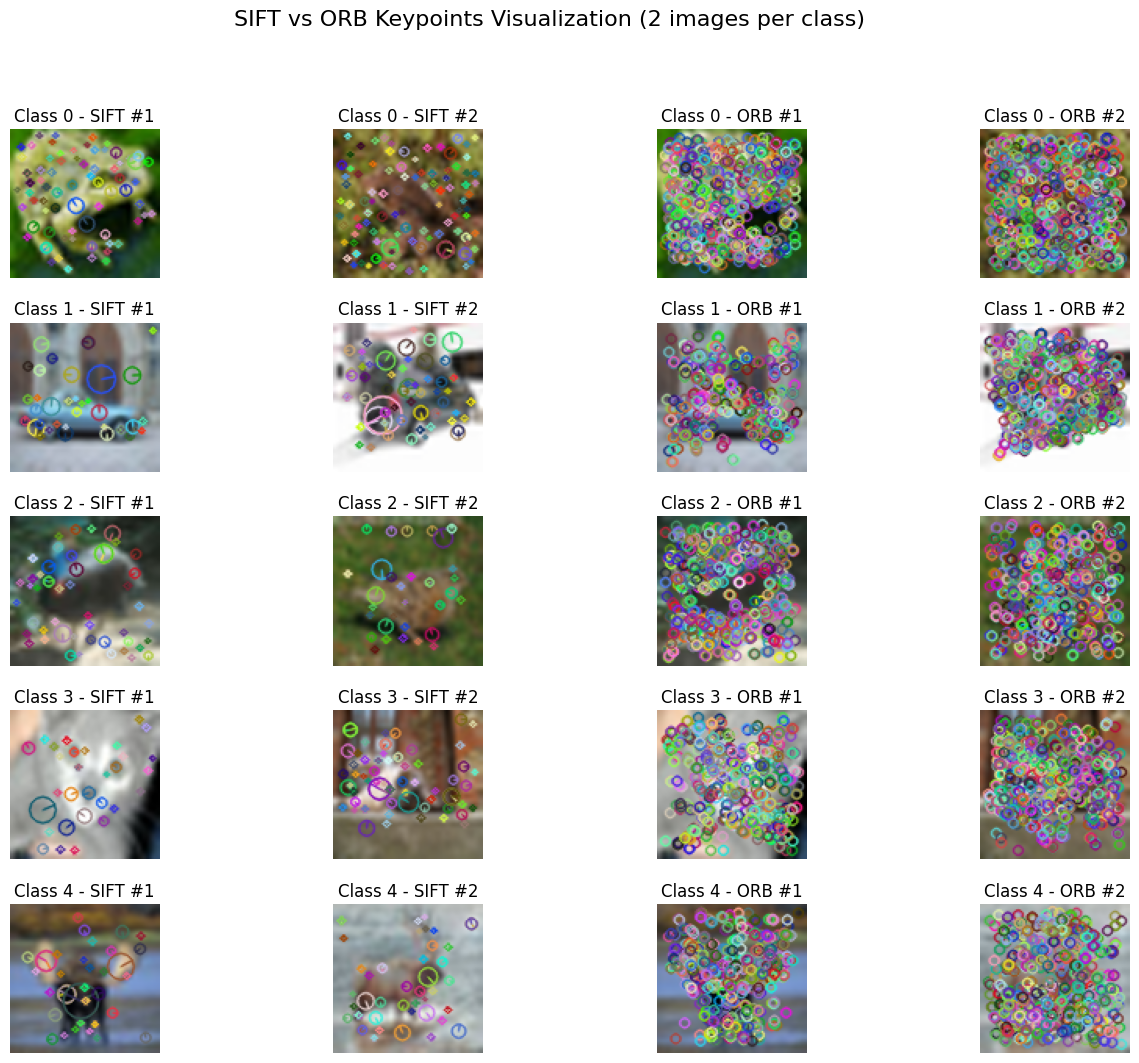

In [120]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import torch

# Convert tensors to numpy if needed
images_np = train_images.numpy() if isinstance(train_images, torch.Tensor) else train_images
labels_np = train_labels.numpy() if isinstance(train_labels, torch.Tensor) else train_labels

# Ensure uint8 type and 0-255 range
if images_np.max() <= 1.0:
    images_np = (images_np * 255).astype(np.uint8)

# Resize images for ORB robustness
resize_size = (96, 96)

# Initialize detectors
sift = cv2.SIFT_create()
orb = cv2.ORB_create(nfeatures=1000, edgeThreshold=5, fastThreshold=5)

# Classes to visualize
classes_to_show = np.unique(labels_np)[:5]  # 5 classes

# For visualization: 5 rows (classes) × 4 columns (2 SIFT + 2 ORB per class)
fig, axes = plt.subplots(len(classes_to_show), 4, figsize=(16, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

for i, cls in enumerate(classes_to_show):
    # Indices of images in this class
    idxs = np.where(labels_np == cls)[0]
    selected_idxs = random.sample(list(idxs), 2)  # pick 2 samples per class

    for j, idx in enumerate(selected_idxs):
        img = images_np[idx]
        img_resized = cv2.resize(img, resize_size, interpolation=cv2.INTER_CUBIC)
        img_gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)

        # --- SIFT ---
        keypoints_sift, _ = sift.detectAndCompute(img_gray, None)
        img_sift = cv2.drawKeypoints(img_resized, keypoints_sift, None,
                                     flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

        # --- ORB ---
        keypoints_orb, _ = orb.detectAndCompute(img_gray, None)
        img_orb = cv2.drawKeypoints(img_resized, keypoints_orb, None,
                                    flags=cv2.DRAW_MATCHES_FLAGS_DEFAULT)

        # Plot SIFT
        axes[i, j].imshow(img_sift)
        axes[i, j].set_title(f"Class {cls} - SIFT #{j+1}")
        axes[i, j].axis('off')

        # Plot ORB
        axes[i, j + 2].imshow(img_orb)
        axes[i, j + 2].set_title(f"Class {cls} - ORB #{j+1}")
        axes[i, j + 2].axis('off')

plt.suptitle("SIFT vs ORB Keypoints Visualization (2 images per class)", fontsize=16)
plt.show()

<a id="section-3"></a>
### **Section 3: Building the Visual Vocabulary (3 points)**

In this section, the task is to create a visual vocabulary by clustering feature descriptors extracted from the images using K-Means. Each cluster center in this vocabulary will represent a visual word. Use the two different extraction techniques you implemented to extract descriptors from a subset of training images that includes all categories, and then apply K-Means clustering to build the vocabulary. The number of clusters is fixed at 1000, but you can experiment with different values when you are tuning the hyperparameters in section 9.

To examine the effect of different amounts of training data, build separate visual vocabularies using 30%, 40%, and 50% subsets of the training images. For faster clustering, the `faiss` library can be used, as it provides an efficient implementation of K-Means. Then, visualize the first 10 clusters for each feature extraction technique and each subset size using PCA to reduce the dimensions to 2D.

**Hints:**
1. Begin by debugging the code with a small number of input images to ensure it functions correctly before running it on larger datasets.
2. If the `faiss` library is not available, K-Means clustering can also be performed using the `sklearn` or `scipy` libraries.
3. For visualization, use PCA from `sklearn.decomposition` to reduce the high-dimensional descriptors to 2D. Display up to 10 clusters in the scatter plot to maintain clarity.


===== Building Visual Vocabulary (30% subset) =====


Extracting SIFT descriptors: 100%|██████████| 1500/1500 [00:03<00:00, 497.55it/s]


→ Extracted 73227 total descriptors with dim 128 (SIFT)
[[  3.   0.   0. ...   5.   1.   2.]
 [  3.  41.  18. ...   0.   0.   0.]
 [  0.  10. 126. ...  17.  21.  36.]
 ...
 [  0.   0.  36. ...   2.   0.   0.]
 [  0.   0.   0. ...   0.   0.   0.]
 [  3.   5.   3. ...   0.   0.   0.]]
Initialization complete
Iteration 0, inertia 7596936192.0.
Iteration 1, inertia 5536695296.0.
Iteration 2, inertia 5423286784.0.
Iteration 3, inertia 5376562176.0.
Iteration 4, inertia 5349782016.0.
Iteration 5, inertia 5331936256.0.
Iteration 6, inertia 5319010816.0.
Iteration 7, inertia 5309333504.0.
Iteration 8, inertia 5301716480.0.
Iteration 9, inertia 5295650304.0.
Iteration 10, inertia 5290910720.0.
Iteration 11, inertia 5287240704.0.
Iteration 12, inertia 5284168192.0.
Iteration 13, inertia 5281602560.0.
Iteration 14, inertia 5279437824.0.
Iteration 15, inertia 5277498368.0.
Iteration 16, inertia 5275774976.0.
Iteration 17, inertia 5274362880.0.
Iteration 18, inertia 5273241600.0.
Iteration 19, iner

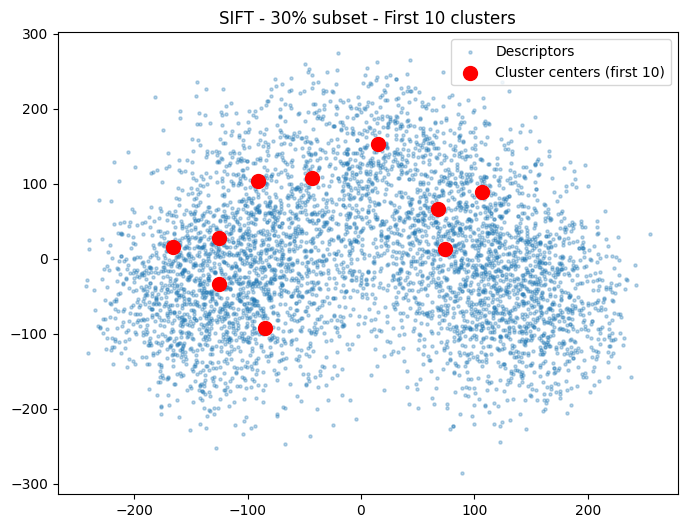

Extracting ORB descriptors: 100%|██████████| 1500/1500 [00:00<00:00, 2170.39it/s]


→ Extracted 17477 total descriptors with dim 32 (ORB)
[[130 204 168 ...  12 181 238]
 [ 15  28 170 ... 249 113 169]
 [169 235  65 ... 158  90 172]
 ...
 [147 207 110 ... 154 121 221]
 [ 82 159 122 ... 227  45  81]
 [ 80  31 122 ... 227 165  81]]
Initialization complete
Iteration 0, inertia 1685065125.0.
Iteration 1, inertia 1326729616.143765.
Iteration 2, inertia 1287140887.8058.
Iteration 3, inertia 1272348772.1313057.
Iteration 4, inertia 1265251468.7544932.
Iteration 5, inertia 1261103836.9136016.
Iteration 6, inertia 1258454943.6453261.
Iteration 7, inertia 1256917657.135384.
Iteration 8, inertia 1255948487.8000128.
Iteration 9, inertia 1255260483.6664457.
Iteration 10, inertia 1254890270.603211.
Iteration 11, inertia 1254698143.3296309.
Iteration 12, inertia 1254595579.1067767.
Iteration 13, inertia 1254520849.9666488.
Iteration 14, inertia 1254454451.5373673.
Iteration 15, inertia 1254407723.436812.
Iteration 16, inertia 1254396869.2594962.
Converged at iteration 16: strict conve

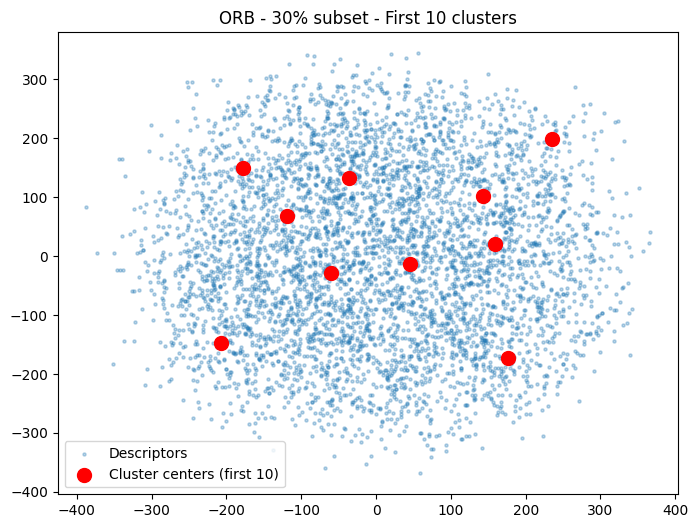


===== Building Visual Vocabulary (40% subset) =====


Extracting SIFT descriptors: 100%|██████████| 2000/2000 [00:03<00:00, 534.03it/s]


→ Extracted 97035 total descriptors with dim 128 (SIFT)
[[  2.  81. 140. ...  61.  27.   4.]
 [  0.   1.  97. ...   0.   0.   0.]
 [  0.   1.   1. ...   0.   0.   0.]
 ...
 [  1.   1.   2. ...  13.   8.   3.]
 [ 24.  43.  18. ...   0.   0.   0.]
 [ 10.  51.  49. ...   0.   0.   0.]]
Initialization complete
Iteration 0, inertia 10122613760.0.
Iteration 1, inertia 7400274432.0.
Iteration 2, inertia 7252584448.0.
Iteration 3, inertia 7188945920.0.
Iteration 4, inertia 7152231424.0.
Iteration 5, inertia 7128325120.0.
Iteration 6, inertia 7111095808.0.
Iteration 7, inertia 7097872896.0.
Iteration 8, inertia 7087477760.0.
Iteration 9, inertia 7079156736.0.
Iteration 10, inertia 7072506880.0.
Iteration 11, inertia 7067082752.0.
Iteration 12, inertia 7062562816.0.
Iteration 13, inertia 7058785280.0.
Iteration 14, inertia 7055643648.0.
Iteration 15, inertia 7052766208.0.
Iteration 16, inertia 7050240512.0.
Iteration 17, inertia 7047993344.0.
Iteration 18, inertia 7045952000.0.
Iteration 19, ine

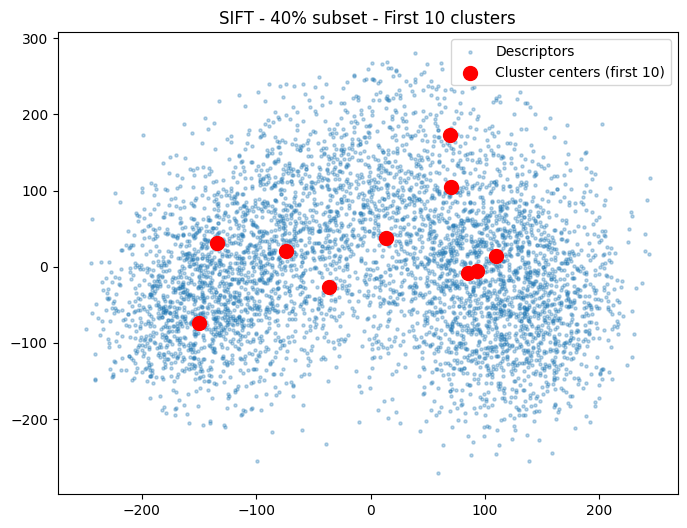

Extracting ORB descriptors: 100%|██████████| 2000/2000 [00:00<00:00, 2164.12it/s]


→ Extracted 23808 total descriptors with dim 32 (ORB)
[[ 34 255 173 ...  24 149 250]
 [ 34 162 194 ... 132 202 140]
 [ 18 251  19 ...  50 167 171]
 ...
 [245 124 255 ... 251 114 114]
 [177 221  61 ...  24 228 122]
 [241 221 127 ... 184 112 120]]
Initialization complete
Iteration 0, inertia 2351659393.0.
Iteration 1, inertia 1868935596.1868887.
Iteration 2, inertia 1815456464.1810684.
Iteration 3, inertia 1794113563.516513.
Iteration 4, inertia 1782518940.671577.
Iteration 5, inertia 1775694963.8391254.
Iteration 6, inertia 1771257551.697885.
Iteration 7, inertia 1768093110.2240891.
Iteration 8, inertia 1765901054.3287117.
Iteration 9, inertia 1764281676.9984848.
Iteration 10, inertia 1763021533.0811543.
Iteration 11, inertia 1762064554.3859096.
Iteration 12, inertia 1761267591.624991.
Iteration 13, inertia 1760781570.028336.
Iteration 14, inertia 1760412778.364328.
Iteration 15, inertia 1760143512.8850014.
Iteration 16, inertia 1759963519.1007643.
Iteration 17, inertia 1759789880.14031

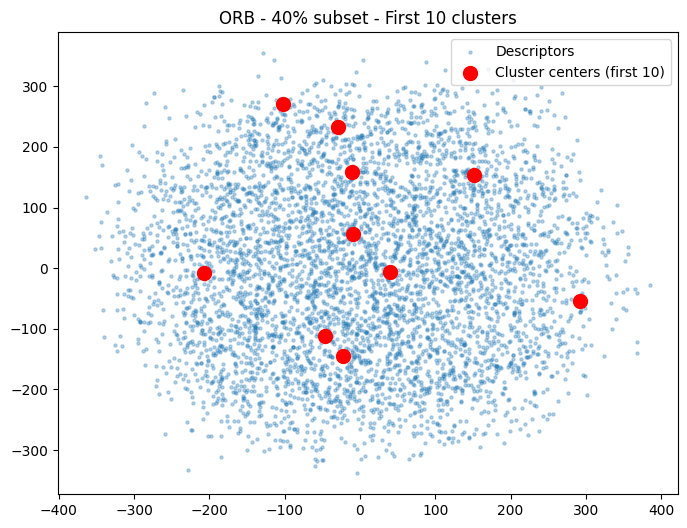


===== Building Visual Vocabulary (50% subset) =====


Extracting SIFT descriptors: 100%|██████████| 2500/2500 [00:05<00:00, 490.43it/s]


→ Extracted 123192 total descriptors with dim 128 (SIFT)
[[  5.   4.   2. ...   0.   0.   1.]
 [  5. 126.  78. ...   0.   0.   0.]
 [ 43. 124.   3. ...   0.  28.  99.]
 ...
 [ 50.   5.   0. ...  17.   3.   1.]
 [  8.   1.   2. ...  40.  10.   0.]
 [  0.   0.   0. ...   1.   0.   0.]]
Initialization complete
Iteration 0, inertia 12850022400.0.
Iteration 1, inertia 9408257024.0.
Iteration 2, inertia 9235001344.0.
Iteration 3, inertia 9161588736.0.
Iteration 4, inertia 9118601216.0.
Iteration 5, inertia 9090752512.0.
Iteration 6, inertia 9070940160.0.
Iteration 7, inertia 9056231424.0.
Iteration 8, inertia 9044505600.0.
Iteration 9, inertia 9034818560.0.
Iteration 10, inertia 9026930688.0.
Iteration 11, inertia 9020665856.0.
Iteration 12, inertia 9015056384.0.
Iteration 13, inertia 9010092032.0.
Iteration 14, inertia 9005792256.0.
Iteration 15, inertia 9001965568.0.
Iteration 16, inertia 8998791168.0.
Iteration 17, inertia 8995961856.0.
Iteration 18, inertia 8993266688.0.
Iteration 19, in

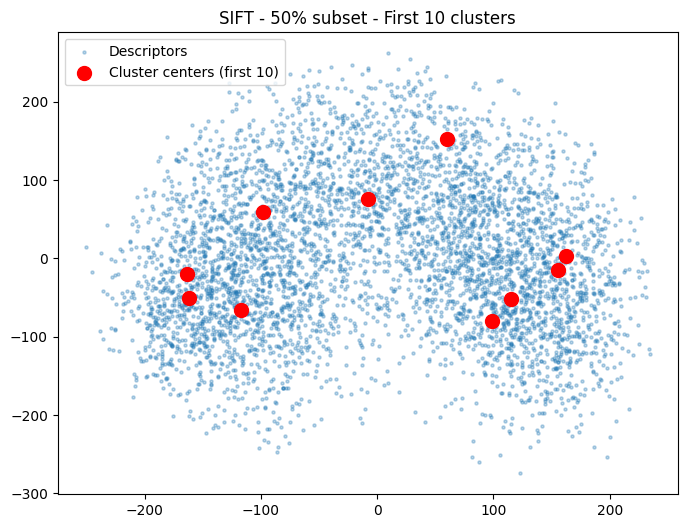

Extracting ORB descriptors: 100%|██████████| 2500/2500 [00:01<00:00, 2258.69it/s]


→ Extracted 29220 total descriptors with dim 32 (ORB)
[[  8  57  59 ... 134 207 251]
 [ 82  40 174 ...   4  39 106]
 [ 73 148 149 ...  96 137  58]
 ...
 [120 177  59 ...  10 199 155]
 [ 90 177  51 ...   6 167 115]
 [ 66 155 190 ...  36 173  91]]
Initialization complete
Iteration 0, inertia 2897433874.0.
Iteration 1, inertia 2315400162.091927.
Iteration 2, inertia 2251520712.0196486.
Iteration 3, inertia 2225554970.9362392.
Iteration 4, inertia 2211318566.748833.
Iteration 5, inertia 2202821413.3901043.
Iteration 6, inertia 2196995704.9588165.
Iteration 7, inertia 2192826972.690321.
Iteration 8, inertia 2189743811.9796934.
Iteration 9, inertia 2187630662.7607975.
Iteration 10, inertia 2185906034.4563546.
Iteration 11, inertia 2184625251.8100195.
Iteration 12, inertia 2183749499.458469.
Iteration 13, inertia 2182943896.95704.
Iteration 14, inertia 2182288479.6962385.
Iteration 15, inertia 2181876098.911394.
Iteration 16, inertia 2181531536.5241575.
Iteration 17, inertia 2181161079.819366

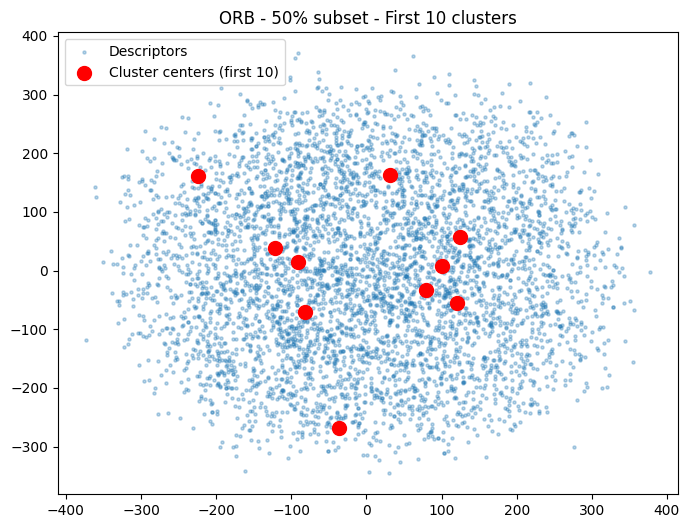

In [121]:
# YOUR CODE HERE

import numpy as np
import random
import cv2
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# ============================================================
# Helper Functions
# ============================================================

def extract_descriptors(images, feature_type="SIFT", max_images=None, upscale_size=(96, 96)):
    """
    Extract descriptors for a subset of images using SIFT or ORB.
    Returns a concatenated descriptor array (N_descriptors, dim)
    """
    if feature_type == "SIFT":
        extractor = cv2.SIFT_create()
    elif feature_type == "ORB":
        extractor = cv2.ORB_create(nfeatures=500)  # Increase keypoints for small images
    else:
        raise ValueError("feature_type must be 'SIFT' or 'ORB'.")

    descriptors_list = []
    selected_idxs = np.arange(len(images)) if max_images is None else np.random.choice(len(images), max_images, replace=False)

    for idx in tqdm(selected_idxs, desc=f"Extracting {feature_type} descriptors"):
        img = images[idx]
        img_up = cv2.resize(img, upscale_size, interpolation=cv2.INTER_CUBIC)
        gray = cv2.cvtColor(img_up, cv2.COLOR_RGB2GRAY)
        _, desc = extractor.detectAndCompute(gray, None)
        if desc is not None and len(desc) > 0:
            descriptors_list.append(desc)

    if len(descriptors_list) == 0:
        raise ValueError(f"No descriptors found for {feature_type}. Try using more images or a different feature extractor.")

    # Concatenate all descriptors
    all_desc = np.vstack(descriptors_list)
    print(f"→ Extracted {all_desc.shape[0]} total descriptors with dim {all_desc.shape[1]} ({feature_type})")
    print(all_desc)
    return all_desc, selected_idxs



def build_vocabulary(descriptors, n_clusters=1000):
    """
    Cluster descriptors into visual words using K-Means (sklearn)
    """
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, verbose=1)
    kmeans.fit(descriptors)
    centers = kmeans.cluster_centers_
    return centers


def visualize_clusters(descriptors, centers, n_show=10, feature_type="SIFT", subset_ratio=None):
    """
    Visualize cluster centers in 2D using PCA.
    We show the first n_show clusters (each as a group of points)
    """
    # Reduce both descriptors and centers to 2D
    pca = PCA(n_components=2)
    reduced_desc = pca.fit_transform(descriptors[np.random.choice(len(descriptors), 5000, replace=False)])
    reduced_centers = pca.transform(centers)

    plt.figure(figsize=(8,6))
    plt.scatter(reduced_desc[:, 0], reduced_desc[:, 1], s=5, alpha=0.3, label="Descriptors")
    plt.scatter(reduced_centers[:n_show, 0], reduced_centers[:n_show, 1], 
                c='red', s=100, label="Cluster centers (first 10)")
    plt.title(f"{feature_type} - {subset_ratio*100:.0f}% subset - First {n_show} clusters")
    plt.legend()
    plt.show()


# ============================================================
# Main Section
# ============================================================

# Assume train_images and train_labels available from previous section
images_np = train_images.numpy() if isinstance(train_images, torch.Tensor) else train_images
if images_np.max() <= 1.0:
    images_np = (images_np * 255).astype(np.uint8)

subset_ratios = [0.3, 0.4, 0.5]
n_clusters = 1000

for ratio in subset_ratios:
    n_imgs = int(len(images_np) * ratio)
    print(f"\n===== Building Visual Vocabulary ({int(ratio*100)}% subset) =====")

    # SIFT
    sift_desc, sift_idxs = extract_descriptors(images_np, feature_type="SIFT", max_images=n_imgs)
    sift_centers  = build_vocabulary(sift_desc, n_clusters=n_clusters)
    visualize_clusters(sift_desc, sift_centers, n_show=10, feature_type="SIFT", subset_ratio=ratio)

    # ORB
    orb_desc, orb_idxs = extract_descriptors(images_np, feature_type="ORB", max_images=n_imgs)
    orb_centers = build_vocabulary(orb_desc, n_clusters=n_clusters)
    visualize_clusters(orb_desc, orb_centers, n_show=10, feature_type="ORB", subset_ratio=ratio)


<a id="section-4"></a>
### **Section 4: Encoding Train Image Features (3 points)**

In this section, the task is to encode image features using the visual vocabulary created earlier. Each image will be represented as a histogram of visual words, reflecting the frequency of each visual word in the image. This representation will allow for comparing images based on their visual content.

To encode an image, identify the nearest visual word (cluster center) for each feature descriptor extracted from the image. Construct a histogram that counts the occurrences of each visual word within the image. The final output will be a collection of histograms, one for each image, where each histogram serves as the feature representation of that image. Once again,  Use the two different extraction techniques you implemented to extract descriptors from the images. Then, encode the images using the visual vocabulary created in the previous step.

**Hint:** Utilize the `faiss` library for efficient nearest neighbor search when assigning each descriptor to the nearest cluster center in the visual dictionary. If `faiss` is not available, consider using other libraries, such as `scikit-learn`, for this step. Once the histograms are obtained, they will be used for further tasks, such as training a classifier. For now, perform the encoding only for the training set.

In [122]:
# YOUR CODE HERE
import numpy as np
import cv2
from tqdm import tqdm

# ============================================================
# Helper Functions
# ============================================================

def extract_image_descriptors(img, feature_type="SIFT"):
    """Extract descriptors from a single image."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    if feature_type == "SIFT":
        extractor = cv2.SIFT_create()
    elif feature_type == "ORB":
        extractor = cv2.ORB_create(nfeatures=500, edgeThreshold = 6)
    else:
        raise ValueError("feature_type must be 'SIFT' or 'ORB'.")
    
    _, desc = extractor.detectAndCompute(gray, None)
    return desc  # may be None


def encode_image(descriptors, vocab):
    """
    Encode a single image into a histogram of visual words.
    descriptors: (N_descriptors, dim)
    vocab: (n_clusters, dim)
    returns: histogram (n_clusters,)
    """
    n_clusters = vocab.shape[0]
    if descriptors is None:
        return np.zeros(n_clusters, dtype=np.float32)
    
    from sklearn.neighbors import NearestNeighbors
    nbrs = NearestNeighbors(n_neighbors=1, algorithm='auto').fit(vocab)
    nn_idx = nbrs.kneighbors(descriptors, return_distance=False).flatten()

    # Build histogram
    hist = np.bincount(nn_idx, minlength=n_clusters).astype(np.float32)
    hist = hist / np.sum(hist)  # normalize histogram
    return hist


def encode_dataset(images, vocab, feature_type="SIFT"):
    """
    Encode an entire dataset of images into BoVW histograms.
    returns: histograms (N_images, n_clusters)
    """
    all_hist = []
    for img in tqdm(images, desc=f"Encoding images with {feature_type}"):
        desc = extract_image_descriptors(img, feature_type=feature_type)
        hist = encode_image(desc, vocab)
        all_hist.append(hist)
    return np.array(all_hist, dtype=np.float32)

# images_np: (N_images, H, W, 3)

# Encode SIFT histograms
sift_histograms = encode_dataset(images_np, sift_centers, feature_type="SIFT")
print("SIFT BoVW histograms shape:", sift_histograms.shape)

# Encode ORB histograms
orb_histograms = encode_dataset(images_np, orb_centers, feature_type="ORB")
print("ORB BoVW histograms shape:", orb_histograms.shape)


Encoding images with SIFT: 100%|██████████| 5000/5000 [00:13<00:00, 373.63it/s]


SIFT BoVW histograms shape: (5000, 1000)


Encoding images with ORB: 100%|██████████| 5000/5000 [00:14<00:00, 355.28it/s]

ORB BoVW histograms shape: (5000, 1000)


<a id="section-5"></a>
### **Section 5: Visualizing the Bag of Visual Words for Each Class (3 points)**

In this section, the task is to visualize the Bag of Visual Words for each class using the histograms generated in the previous step. The goal is to plot the mean histogram of visual words for each class, showing the distribution of visual words across the different categories in the training set.

Use the two different extraction techniques you implemented for this visualization. For each technique, calculate the mean histogram for each class and create a bar plot to display these histograms. Ensure that the plots are labeled clearly with the class names and feature descriptor types.

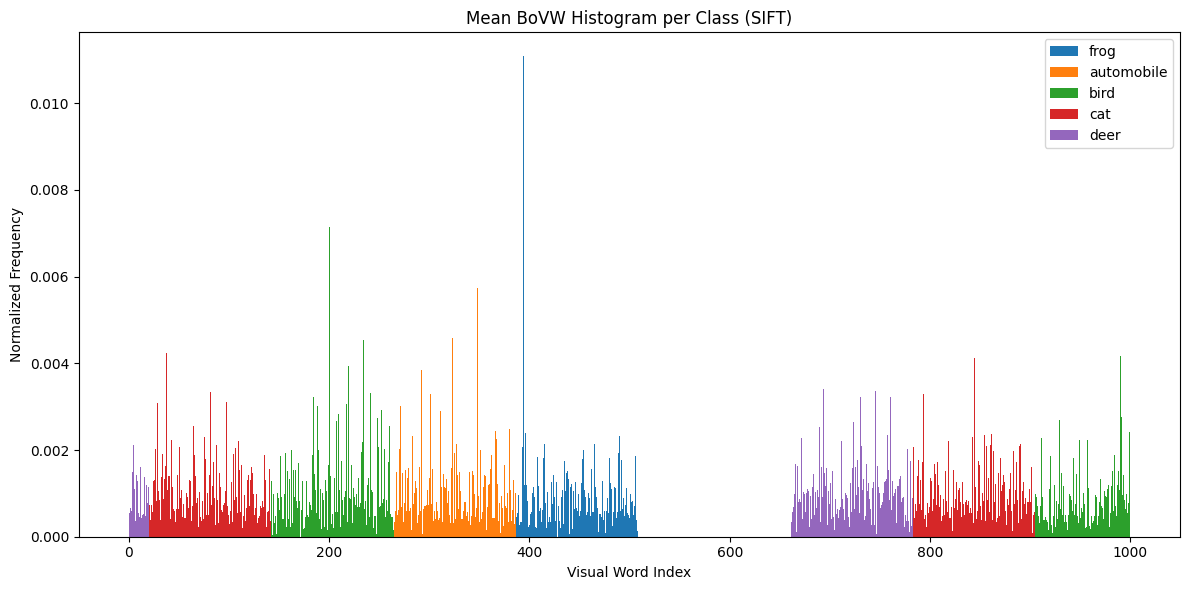

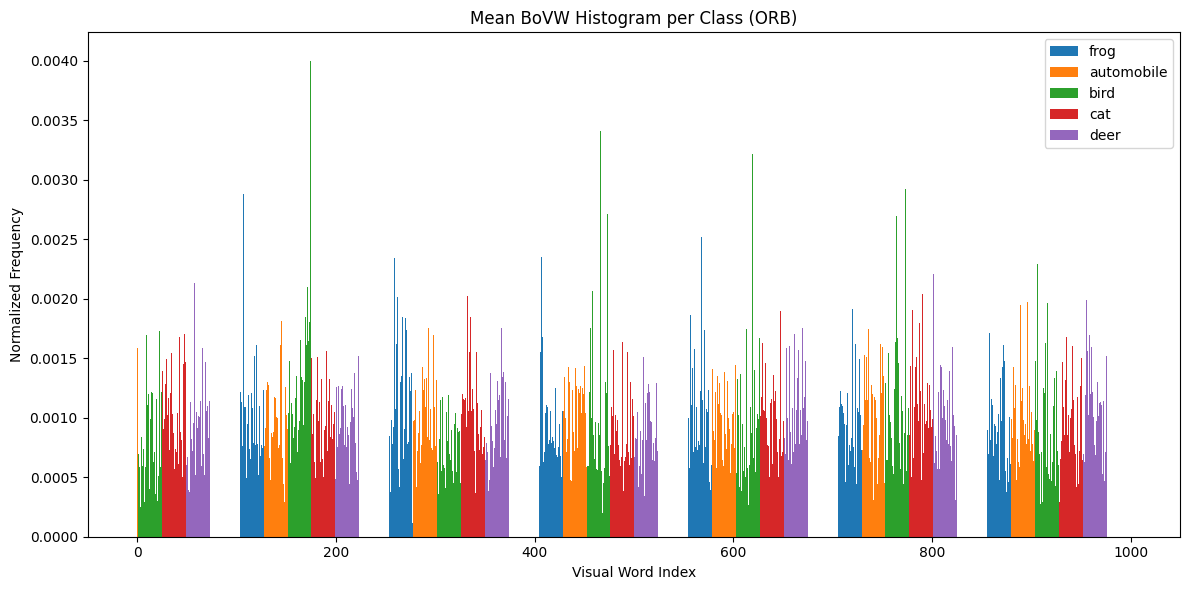

In [123]:
def plot_mean_histograms(histograms, labels, class_names, feature_type):
    n_classes = len(class_names)
    n_clusters = histograms.shape[1]

    plt.figure(figsize=(12, 6))
    for i, class_name in enumerate(class_names):
        class_hist = histograms[np.array(labels) == i]
        if len(class_hist) == 0:
            continue

        mean_hist = np.mean(class_hist, axis=0)
        plt.bar(np.arange(n_clusters) + i * (0.8 / n_classes),
                mean_hist,
                width=(0.8 / n_classes),
                label=class_name)

    plt.title(f"Mean BoVW Histogram per Class ({feature_type})")
    plt.xlabel("Visual Word Index")
    plt.ylabel("Normalized Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

class_names = ["frog", "automobile", "bird", "cat", "deer"]

# Plot for train set
plot_mean_histograms(sift_histograms, train_mapped_labels, class_names, feature_type="SIFT")
plot_mean_histograms(orb_histograms, train_mapped_labels, class_names, feature_type="ORB")

<a id="section-6"></a>
### **Section 6: Encoding Test Image Features (0 points)**

In this section, the task is to encode the test image features using the visual vocabulary created from the training set. Similar to the previous encoding step, each test image will be represented as a histogram of visual words, which will then be used for evaluating classification performance.

Use the same two feature extraction techniques you selected earlier. Extract keypoints and descriptors for the test images, then encode these images using the visual vocabulary. This will allow you to compare the encoded features of test images against those of the training set.

**Hint:** Reuse the functions developed earlier for extracting keypoints, descriptors, and encoding images. Ensure that you use the visual vocabulary constructed with the training images for consistency.

In [124]:
test_images_np = test_images.numpy() if isinstance(test_images, torch.Tensor) else test_images
if test_images_np.max() <= 1.0:
    test_images_np = (test_images_np * 255).astype(np.uint8)

# Encode SIFT histograms for test images
test_sift_histograms = encode_dataset(test_images_np, sift_centers, feature_type="SIFT")
print("Test SIFT histograms shape:", test_sift_histograms.shape)

# Encode ORB histograms for test images
test_orb_histograms = encode_dataset(test_images_np, orb_centers, feature_type="ORB")
print("Test ORB histograms shape:", test_orb_histograms.shape)

Encoding images with SIFT: 100%|██████████| 1000/1000 [00:02<00:00, 381.20it/s]


Test SIFT histograms shape: (1000, 1000)


Encoding images with ORB: 100%|██████████| 1000/1000 [00:02<00:00, 496.44it/s]


Test ORB histograms shape: (1000, 1000)


<a id="section-7"></a>
### **Section 7: Training the Classifiers (5 points)**

In this section, the task is to create two one-vs-rest (OvR) SVM classifiers using the 50% of the training data that was **not** used for creating the visual dictionary. This ensures that the classifiers are trained on a different subset of data, providing a more robust evaluation of the visual vocabulary's effectiveness.

For each of the two selected feature extraction techniques, create one-vs-rest classifiers for all classes. For now, use default parameter values when training the classifiers; you will experiment with different hyperparameters in later steps.

**Note:** Training an OvR classifier can take around 5 to 7 minutes. Therefore, it's advisable to first test your code with a smaller subset of the training data to verify that your implementation works correctly before running it on the full dataset.

In [125]:
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier  

all_indices = np.arange(len(labels_np))

# --- SIFT ---
train_svm_indices_sift = np.setdiff1d(all_indices, sift_idxs)  # complement of vocab images
X_train_sift = sift_histograms[train_svm_indices_sift]
y_train_sift = labels_np[train_svm_indices_sift]

svm_sift = OneVsRestClassifier(SVC(kernel='linear', random_state=42))
svm_sift.fit(X_train_sift, y_train_sift)

# --- ORB ---
train_svm_indices_orb = np.setdiff1d(all_indices, orb_idxs)  # complement of vocab images
X_train_orb = orb_histograms[train_svm_indices_orb]
y_train_orb = labels_np[train_svm_indices_orb]

svm_orb = OneVsRestClassifier(SVC(kernel='linear', random_state=42))
svm_orb.fit(X_train_orb, y_train_orb)

OneVsRestClassifier(estimator=SVC(kernel='linear', random_state=42))

<a id="section-8"></a>
### **Section 8: Evaluating the Classifiers (12 points)**

In this section, you will evaluate the performance of your one-vs-rest (OvR) SVM classifiers on the test data. The goal is to classify each test image using each binary classifier and rank the images based on the classification scores, resulting in a ranked list of images for each class. Ideally, images belonging to the target class should appear at the top of the respective list. To conduct this evaluation, use the test image histograms generated earlier for the two selected feature extraction techniques. Classify each test image with each classifier, rank them based on their confidence scores, and then compute the Mean Average Precision (mAP) across all classes. The mAP for a single class $c$ is defined as:

$
\text{mAP}_c = \frac{1}{m_c} \sum_{i=1}^{n} \frac{f_c(x_i)}{i}
$

where:
- $n$ is the total number of images ($n = 50 \times 5 = 250$),
- $m_c$ is the number of images of class $c$ ($m_c = 50$),
- $x_i$ is the $i^{th}$ image in the ranked list $X = \{ x_1, x_2, \dots, x_n \}$,
- $f_c$ is a function that returns the number of images of class $c$ in the first $i$ images if $x_i$ is of class $c$, and 0 otherwise.

For instance, if you are retrieving images of class "R" and the sequence of ranked images is $[R, R, T, R, T, T, R, T]$, then $n = 8$, $m_c = 4$, and:

$
AP = \frac{1}{4} \left( \frac{1}{1} + \frac{2}{2} + \frac{0}{3} + \frac{3}{4} + \frac{0}{5} + \frac{0}{6} + \frac{4}{7} + \frac{0}{8} \right).
$

In addition to the quantitative analysis, perform a qualitative analysis by visualizing the top-5 and bottom-5 ranked test images.

mAP per class: [0.24442796602871059, 0.5014278475683219, 0.39648368101937737, 0.2540587986668237, 0.2588235073557598]
Mean mAP: 0.3310443601277987
SIFT Ranking


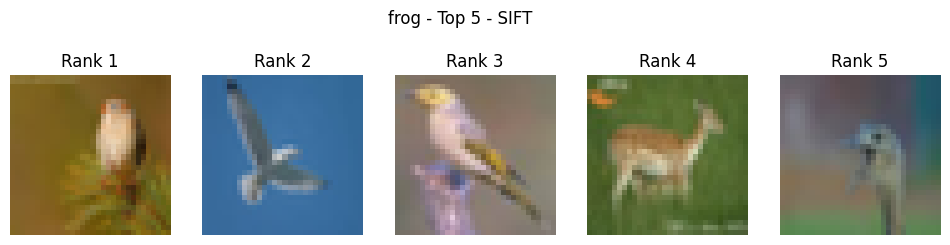

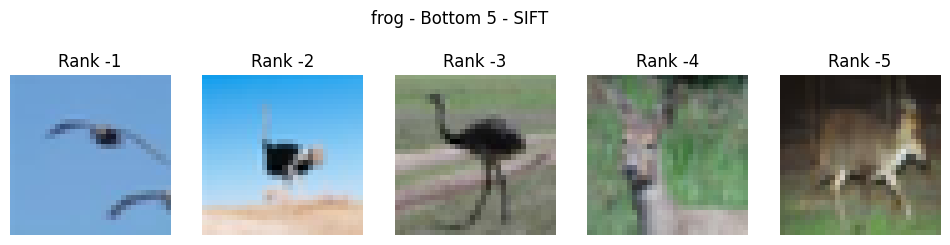

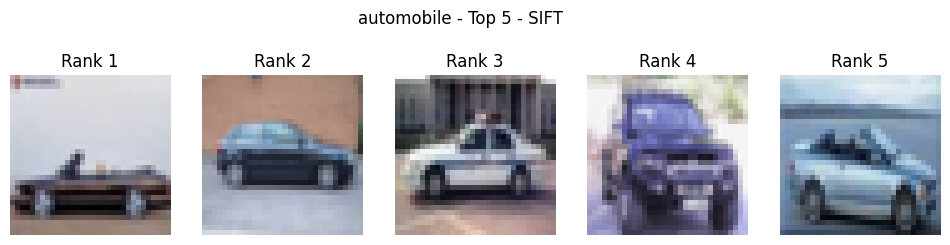

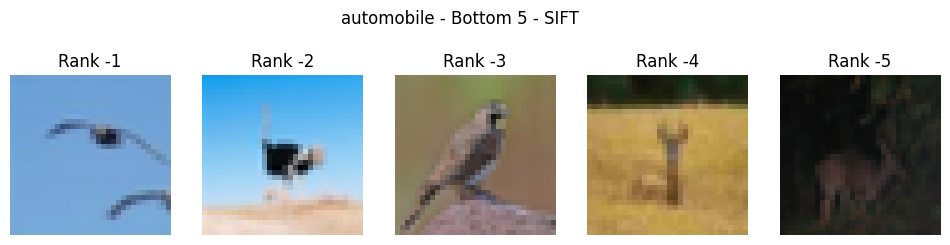

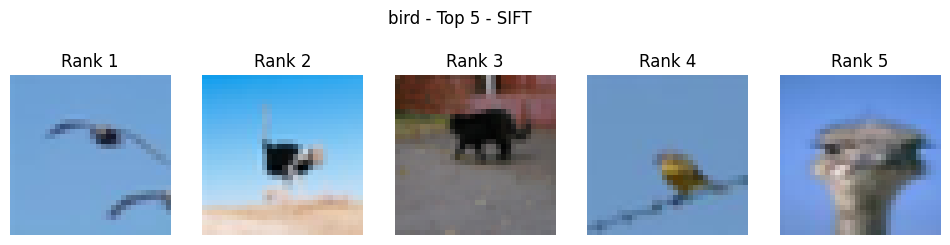

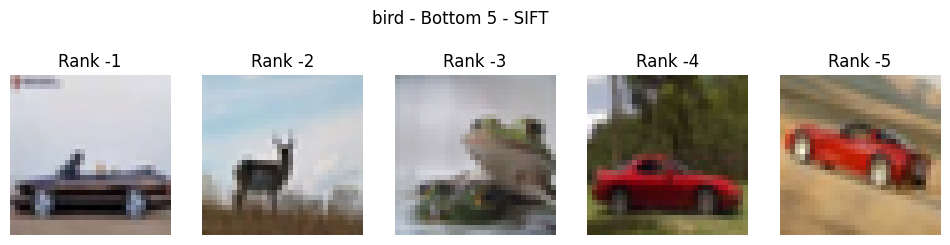

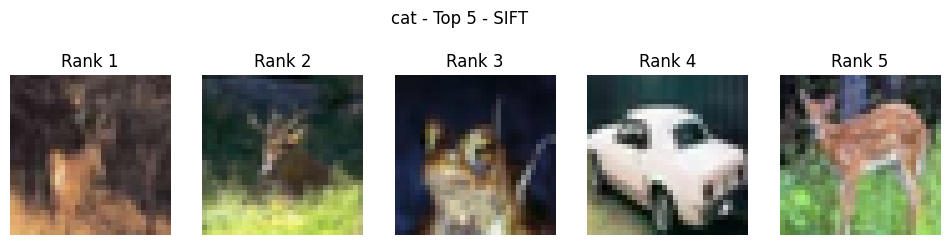

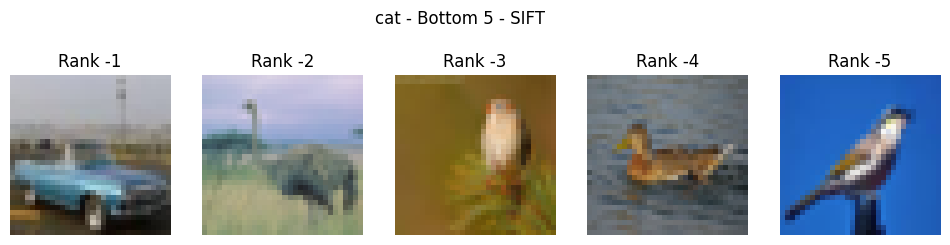

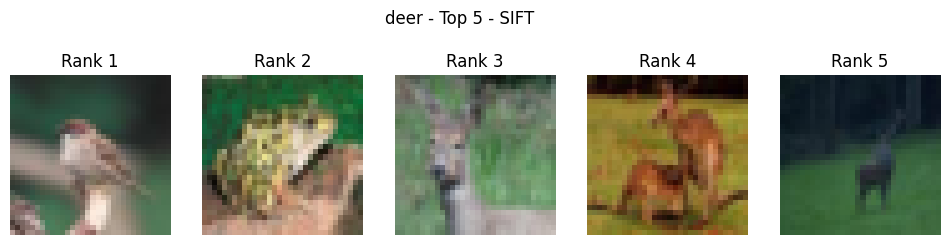

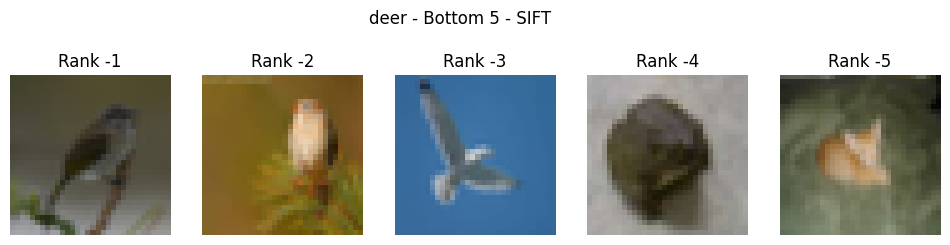

mAP per class: [0.27178783537884355, 0.26111375747984694, 0.2680480370050979, 0.2173781718870121, 0.2308935666363566]
Mean mAP: 0.2498442736774314
ORB Ranking


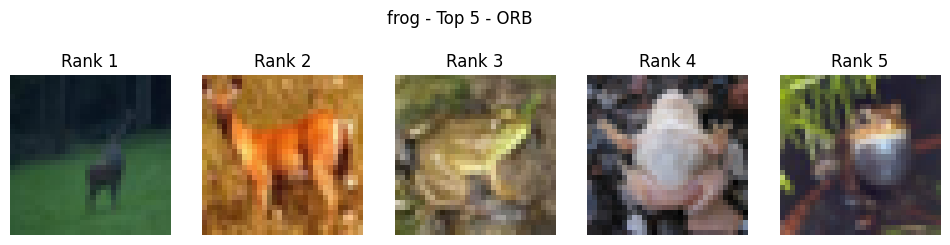

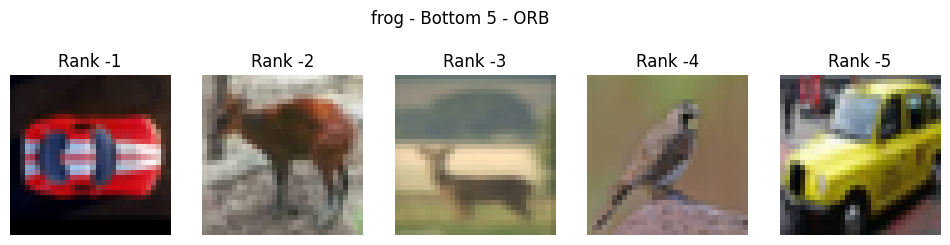

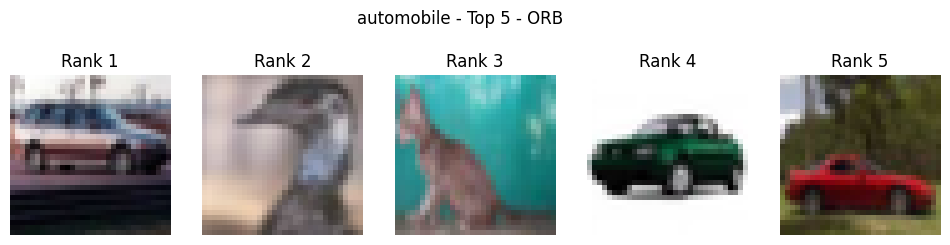

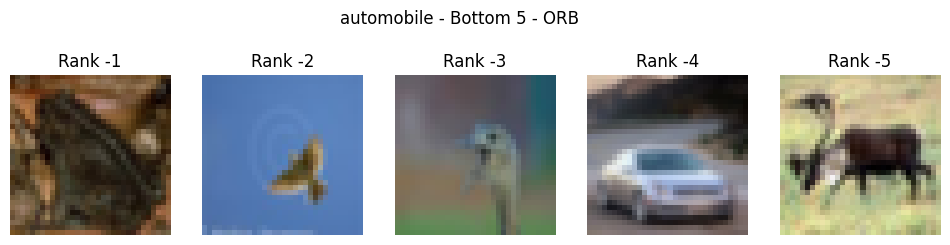

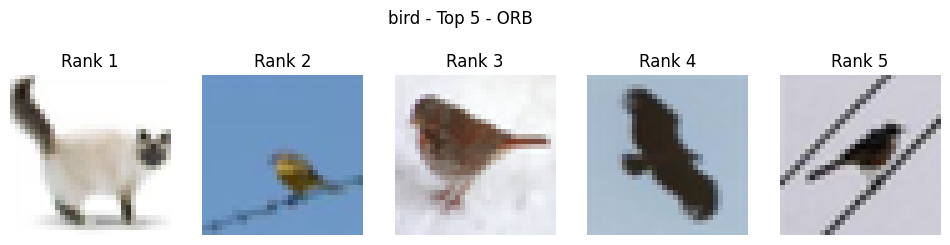

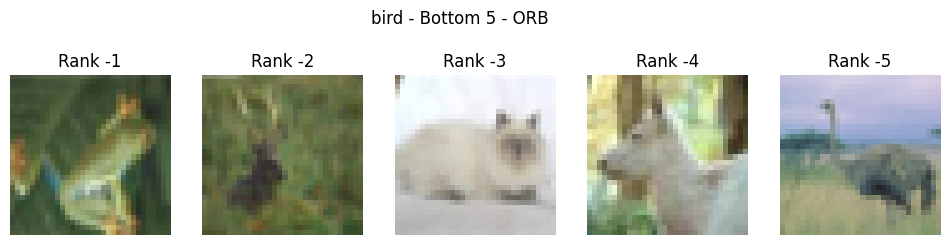

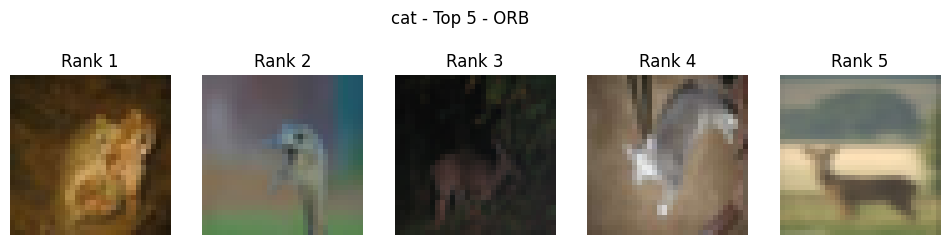

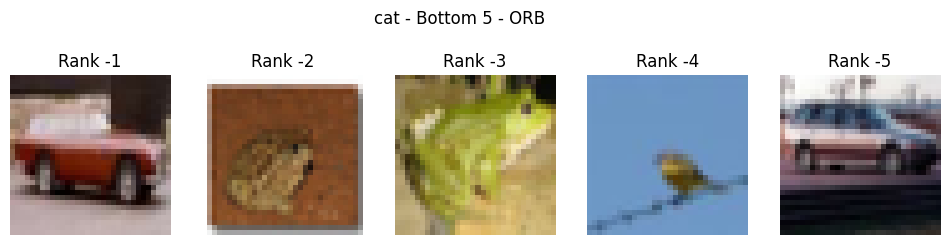

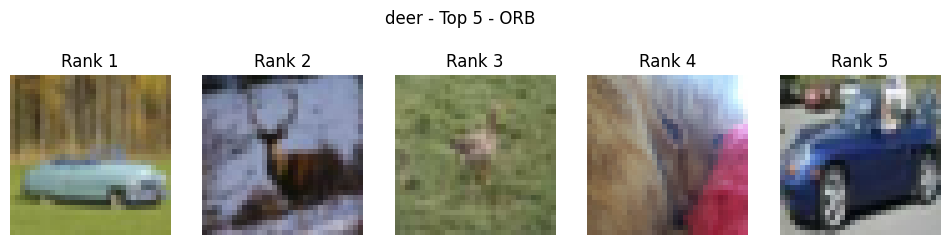

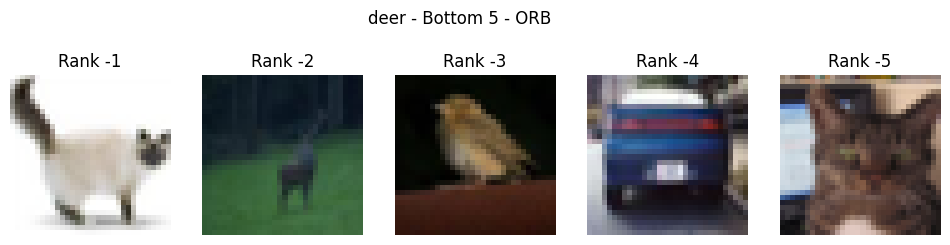

In [137]:
def evaluate_classifiers(classifier, test_hist, ovr_classifier, images, labels, class_names=None, top_k=5):
    """
    Evaluate OvR SVM classifiers using mAP and visualize top/bottom ranked images.
    
    Parameters:
    - test_hist: (N_test, n_features) BoVW histograms
    - classifiers: list of trained SVM classifiers, one per class
    - images: array of test images
    - labels: class labels
    - class_names: list of class names
    - top_k: number of images to show at top/bottom
    """
    classifiers = ovr_classifier.estimators_
    n_classes = 5
    n_images = len(classifiers)

    # compute scores
    scores = ovr_classifier.decision_function(test_hist)

    # rank images for each class
    ranked_indices = [np.argsort(-scores[:, i]) for i in range(n_classes)]

    # compute mAP
    def compute_ap(ranked_idx, true_labels, target_class):
        m_c = np.sum(true_labels == target_class)
        if m_c == 0:
            return 0.0
        count = 0
        ap_sum = 0
        for rank, idx in enumerate(ranked_idx, 1):
            if true_labels[idx] == target_class:
                count += 1
                ap_sum += count / rank
        return ap_sum / m_c

    maps = [compute_ap(ranked_indices[i], labels, i) for i in range(n_classes)]
    mean_ap = np.mean(maps)
    print("mAP per class:", maps)
    print("Mean mAP:", mean_ap)

    # visualize top/bottom images
    print(f"{classifier} Ranking")
    for i in range(n_classes):
        name = class_names[i] if class_names else str(i)
        idxs = ranked_indices[i]

        # top-k
        plt.figure(figsize=(12,3))
        for j in range(top_k):
            plt.subplot(1, top_k, j+1)
            plt.imshow(images[idxs[j]])
            plt.axis('off')
            plt.title(f"Rank {j+1}")
        plt.suptitle(f"{name} - Top {top_k} - {classifier}")
        plt.show()

        # bottom-k
        plt.figure(figsize=(12,3))
        for j in range(1, top_k+1):
            plt.subplot(1, top_k, j)
            plt.imshow(images[idxs[-j]])
            plt.axis('off')
            plt.title(f"Rank {-j}")
        plt.suptitle(f"{name} - Bottom {top_k} - {classifier}")
        plt.show()

    return maps, mean_ap, ranked_indices

# Example for SIFT
maps_sift, mean_ap_sift, ranked_sift = evaluate_classifiers(
    classifier="SIFT",
    test_hist=test_sift_histograms,
    ovr_classifier=svm_sift,
    images=test_images_np,
    labels=test_labels.numpy(),
    class_names = ["frog", "automobile", "bird", "cat", "deer"],
    top_k=5
)

# Example for ORB
maps_orb, mean_ap_orb, ranked_orb = evaluate_classifiers(
    classifier="ORB",
    test_hist=test_orb_histograms,
    ovr_classifier=svm_orb,
    images=test_images_np,
    labels=test_labels.numpy(),
    class_names = ["frog", "automobile", "bird", "cat", "deer"],
    top_k=5
)

<a id="section-9"></a>
### **Section 9: Hyperparameter Search (16 points)**

In this section, the task is to perform an extensive hyperparameter search to optimize the performance of your classifiers. You will experiment with various parameters, including the number of visual words (e.g., 500, 1000, 1500), different training subset sizes (e.g., 30%, 40%, 50%), SVM parameters (e.g., kernel types like 'linear' or 'rbf', regularization parameter $C$ values such as 0.1, 1, 10, and gamma settings like 'scale' or specific values such as 0.01, 0.001), and settings of the feature extractors (e.g., the number of keypoints or scale levels). Start by testing your code on the smallest subset to ensure it functions correctly before proceeding with a full hyperparameter search. Once validated, conduct the search using larger subsets and systematically iterate through the different parameter combinations, potentially using nested loops or grid search. Be sure to record the performance results for each combination to identify the best settings based on metrics like the Mean Average Precision (mAP).

In [139]:
import optuna

y_test = ("frog", "automobile", "bird", "cat", "deer")

def objective(trial, feature_type='SIFT'):
    # Hyperparameters to tune
    n_clusters = trial.suggest_categorical("n_clusters", [500, 1000, 1500])
    subset_ratio = trial.suggest_categorical("subset_ratio", [0.3, 0.4, 0.5])
    kernel = trial.suggest_categorical("kernel", ['linear', 'rbf'])
    C = trial.suggest_float("C", 0.1, 10, log=True)
    gamma = 'scale'
    if kernel == 'rbf':
        gamma = trial.suggest_float("gamma", 0.001, 0.1, log=True)

    # 1️⃣ Extract descriptors
    n_imgs = int(len(images_np) * subset_ratio)
    descriptors, selected_idxs = extract_descriptors(images_np, feature_type=feature_type, max_images=n_imgs)

    # 2️⃣ Build vocabulary
    vocab = build_vocabulary(descriptors, n_clusters=n_clusters)

    # 3️⃣ Encode dataset
    histograms = encode_dataset(images_np, vocab, feature_type=feature_type)

    # 4️⃣ Prepare training set (exclude vocab images)
    train_indices = np.setdiff1d(np.arange(len(images_np)), selected_idxs)
    X_train = histograms[train_indices]
    y_train = labels_np[train_indices]

    # 5️⃣ Train OvR SVM
    svm = OneVsRestClassifier(SVC(kernel=kernel, C=C, gamma=gamma, random_state=42))
    svm.fit(X_train, y_train)

    # 6️⃣ Evaluate mean mAP
    X_test = encode_dataset(test_images_np, vocab, feature_type=feature_type)
    _, mean_ap, _ = evaluate_classifiers(
        classifier=feature_type,
        test_hist=X_test,
        ovr_classifier=svm,
        images=test_images_np,
        labels=test_labels.numpy(),
        class_names = y_test,
        top_k=0  # skip plotting 
    )

    trial.report(mean_ap, step=0)


    return mean_ap  # Optuna maximizes this by default if we set direction='maximize'

# --- Run Optuna Study ---
study_sift = optuna.create_study(direction='maximize')
study_sift.optimize(lambda trial: objective(trial, feature_type='SIFT'), n_trials=30)

study_orb = optuna.create_study(direction='maximize')
study_orb.optimize(lambda trial: objective(trial, feature_type='ORB'), n_trials=30)

# --- Best Results ---
print("Best SIFT:", study_sift.best_params, "mAP:", study_sift.best_value)
print("Best ORB:", study_orb.best_params, "mAP:", study_orb.best_value)

[I 2025-10-16 14:06:38,481] A new study created in memory with name: no-name-d68bbec2-a023-4304-8ca8-8bdd76385a47
Extracting SIFT descriptors: 100%|██████████| 1500/1500 [00:03<00:00, 497.12it/s]


→ Extracted 74028 total descriptors with dim 128 (SIFT)
[[ 4.  4. 12. ... 28. 43. 24.]
 [ 1. 30. 47. ...  0.  0.  4.]
 [ 2.  3.  0. ... 32. 18. 20.]
 ...
 [13.  8.  1. ...  0.  0.  0.]
 [ 7.  9.  2. ...  0.  2. 62.]
 [ 1.  6. 46. ...  0.  0.  0.]]
Initialization complete
Iteration 0, inertia 7285513216.0.
Iteration 1, inertia 5351352832.0.
Iteration 2, inertia 5239944704.0.
Iteration 3, inertia 5192694784.0.
Iteration 4, inertia 5165696000.0.
Iteration 5, inertia 5148014080.0.
Iteration 6, inertia 5136035840.0.
Iteration 7, inertia 5127275520.0.
Iteration 8, inertia 5120336384.0.
Iteration 9, inertia 5115168768.0.
Iteration 10, inertia 5111145472.0.
Iteration 11, inertia 5107992576.0.
Iteration 12, inertia 5105452032.0.
Iteration 13, inertia 5103334400.0.
Iteration 14, inertia 5101582848.0.
Iteration 15, inertia 5100120576.0.
Iteration 16, inertia 5098915328.0.
Iteration 17, inertia 5097988608.0.
Iteration 18, inertia 5097288704.0.
Iteration 19, inertia 5096747008.0.
Iteration 20, iner

Encoding images with SIFT: 100%|██████████| 1000/1000 [00:04<00:00, 200.48it/s]


mAP per class: [0.2449652547803364, 0.5188871708120589, 0.36643446427132814, 0.26772922111495295, 0.23991871445540386]
Mean mAP: 0.32758696508681606
SIFT Ranking


<Figure size 1200x300 with 0 Axes>

...

<Figure size 1200x300 with 0 Axes>

<Figure size 1200x300 with 0 Axes>

<Figure size 1200x300 with 0 Axes>

[I 2025-10-16 15:15:26,103] Trial 29 finished with value: 0.24923508662415586 and parameters: {'n_clusters': 1000, 'subset_ratio': 0.3, 'kernel': 'linear', 'C': 0.8553594089596832}. Best is trial 0 with value: 0.26772438074963517.


Best SIFT: {'n_clusters': 1500, 'subset_ratio': 0.3, 'kernel': 'rbf', 'C': 2.3959423780605342, 'gamma': 0.059756938448931415} mAP: 0.3353037531085742
Best ORB: {'n_clusters': 500, 'subset_ratio': 0.3, 'kernel': 'linear', 'C': 1.2611699273408423} mAP: 0.26772438074963517


<a id="section-10"></a>
### **Section 10: Using CLIP for Image Classification (5 points)**

**<span style="color:red">⚠️ NOTE: This section should NOT be included in the report. It is only meant to be completed in the code cells. The purpose of this task is to introduce you to a more state-of-the-art model (CLIP) compared to Bag of Visual Words (BoVW). Vision Transformers (ViT) will be covered in more detail in the Deep Learning 1 course next period!</span>**

In this section, you will use a pre-trained CLIP model for image classification. CLIP (Contrastive Language-Image Pretraining) is a vision-language transformer model trained on a large dataset of images and text. It consists of two main components: a Vision Transformer (ViT) and a text Transformer. The ViT encodes images by dividing them into patches (tokens), flattening each patch into a vector, and passing them through a sequence of Transformer layers to produce an encoded representation of the image.

For this task, you will use the visual transformer component of CLIP to extract encoded representations of the input images. While this is not the typical way to use CLIP (which involves encoding both images and text for similarity comparison), it provides an interesting application of this state-of-the-art model for image classification.

**To Install CLIP:**
```python
pip install git+https://github.com/openai/CLIP.git
```

**Additional Reading (if you're interested):**
- [OpenAI CLIP Overview](https://openai.com/clip)
- [Vision Transformer (ViT) Paper](https://arxiv.org/abs/2010.11929)
- [Tutorial on Vision Transformers](https://d2l.ai/chapter_attention-mechanisms-and-transformers/vision-transformer.html)
- [UvA's Deep Learning Introduction to ViTs](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial15/Vision_Transformer.html)

First, create DataLoaders for both the training and test datasets by filtering the CIFAR-10 dataset to include only the selected classes: frog, automobile, bird, cat, and deer. Use a batch size of 16 for both DataLoaders, and resize the images to 224x224 to match the input size requirements for CLIP. Remember to normalize the images using the appropriate mean and standard deviation. Use a training set size of 1000 images per class and a test set size of 200 images per class.

In [ ]:
# YOUR CODE HERE

Next, we load a pre-trained CLIP model, which is a vision-language transformer designed to predict the text that describes an image and vice versa. The model consists of two components: a Vision Transformer (ViT) for encoding images and a text Transformer for encoding text. 

In [ ]:
import clip

# Setup the model and the preprocessor
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load the pre-trained CLIP model
model, preprocess = clip.load("ViT-B/32", device=device)

ModuleNotFoundError: No module named 'clip'

To extract the visual tokens using the CLIP model, start by initializing two empty lists: one for storing the image features and another for the labels. Use `tqdm` to create a progress bar that tracks the extraction process over the DataLoader. Iterate through the DataLoader, extracting images and labels. Disable gradient computation, and then encode the images with `model.encode_image(images)`. Append the encoded features and labels to their respective lists. Remember, the output from the model will have the shape `(batch_size, 512)` due to batched processing, if your are using a single you should reshape the output to `(512,)` to remove the batch dimension.

In this example, we will use the class token as the visual representation of the image. The class token is a 512-dimensional vector that represents the image. We will use this vector to train a classifier to classify the images.

**Note:** The CLIP model is quite large and may take some time to extract features from the images. You can use the `tqdm` library to create a progress bar that shows the extraction progress. It is recommended to test the code with a smaller subset of images to ensure it functions correctly before running it on the full dataset. With the default batch size of 16 and a training set size of 1000 images, the extraction process may take a 10-20 minutes.

In [ ]:
# YOUR CODE HERE

In [ ]:
# Stack the (batched) visual tokens extracted from the images. The resulting shape will be (number_of_images, 512).
stacked_image_features = torch.cat(image_features_list)
stacked_target_labels = torch.cat(target_labels_list)

To train a classifier using the visual tokens, start by initializing an SVM classifier using `SVC()` from `scikit-learn`. You can play around with different hyperparameters such as kernel type, regularization parameter, and gamma to find the best configuration. Finally, use the `fit` method to train the classifier on the visual image features and labels.

In [ ]:
# YOUR CODE HERE

To evaluate the classifier, start by extracting the visual tokens from the test images using the same method applied to the training set. Loop through the test DataLoader, encode each batch of images using the model (e.g., `model.encode_image(images)`), and store the results in separate lists for the features and labels. After extracting all the features, stack them into a single tensor for both the features and labels. This process will prepare the test data for use in evaluating the classifier's performance.

In [ ]:
# YOUR CODE HERE

To evaluate the performance of your classifier, use the test set features you extracted earlier. First, generate predictions for the test set by passing the stacked test features into your trained classifier's `predict` method. Next, use the `classification_report` function from `sklearn.metrics` to create a detailed report that includes metrics such as precision, recall, and F1-score for each class. Finally, print the report to analyze how well your classifier performs across the different classes.

In [ ]:
# YOUR CODE HERE

<a id="section-x"></a>
### **Section X: Individual Contribution Report *(Mandatory)***

Because we want each student to contribute fairly to the submitted work, we ask you to fill out the textcells below. Write down your contribution to each of the assignment components in percentages. Naturally, percentages for one particular component should add up to 100% (e.g. 30% - 30% - 40%). No further explanation has to be given.

| Name | Contribution on Research | Contribution on Programming | Contribution on Writing |
| -------- | ------- | ------- | ------- |
|  | - % | - % | - % |
|  | - % | - % | - % |
|  | - % | - % | - % |
|  | - % | - % | - % |

### - End of Notebook -